# Seaborn: Statistical Data Visualization

## What is Seaborn?
**Seaborn** is a statistical data visualization library built on top of Matplotlib, created by **Michael Waskom** in 2012. It provides a higher-level API for drawing attractive, informative statistical graphics.

### Why Seaborn over Matplotlib?
| Feature | Matplotlib | Seaborn |
|---------|-----------|--------|
| Default aesthetics | Basic | Beautiful |
| Statistical plots | Manual | Built-in |
| Pandas integration | Partial | Seamless |
| Code verbosity | High | Low |
| Customization | Full control | Slightly less |

### Seaborn's Plot Categories
| Category | Function | Purpose |
|----------|----------|---------|
| Relational | `relplot`, `scatterplot`, `lineplot` | Relationships between variables |
| Distribution | `displot`, `histplot`, `kdeplot`, `ecdfplot` | Data distributions |
| Categorical | `catplot`, `boxplot`, `violinplot`, `stripplot`, `swarmplot`, `barplot`, `countplot` | Categorical comparisons |
| Regression | `lmplot`, `regplot`, `residplot` | Linear relationships |
| Matrix | `heatmap`, `clustermap` | Matrix visualization |
| Multi-grid | `FacetGrid`, `PairGrid`, `pairplot`, `jointplot` | Multi-panel figures |

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid', palette='husl')
print(f'Seaborn version: {sns.__version__}')

# Load built-in datasets
tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')
flights = sns.load_dataset('flights')
penguins = sns.load_dataset('penguins')
titanic = sns.load_dataset('titanic')

print('Tips dataset shape:', tips.shape)
print('Tips columns:', tips.columns.tolist())
tips.head()

Seaborn version: 0.13.2
Tips dataset shape: (244, 7)
Tips columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1. Relational Plots

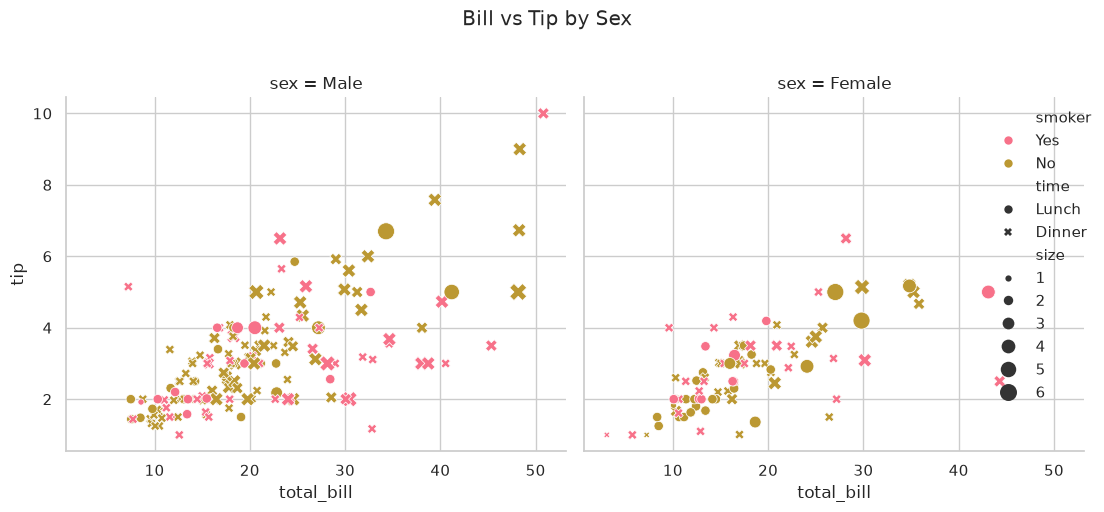

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex', size='size',
                sizes=(20, 200), alpha=0.7, ax=axes[0])
axes[0].set_title('Total Bill vs Tip')

# Line plot with confidence interval
fmri = sns.load_dataset('fmri')
sns.lineplot(data=fmri, x='timepoint', y='signal', hue='region',
             style='event', ax=axes[1])
axes[1].set_title('FMRI Signal over Time')

# relplot (figure-level) with facets
plt.close()
g = sns.relplot(data=tips, x='total_bill', y='tip', col='sex', hue='smoker',
                style='time', size='size', sizes=(20, 150))
g.fig.suptitle('Bill vs Tip by Sex', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sns_relational.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Distribution Plots

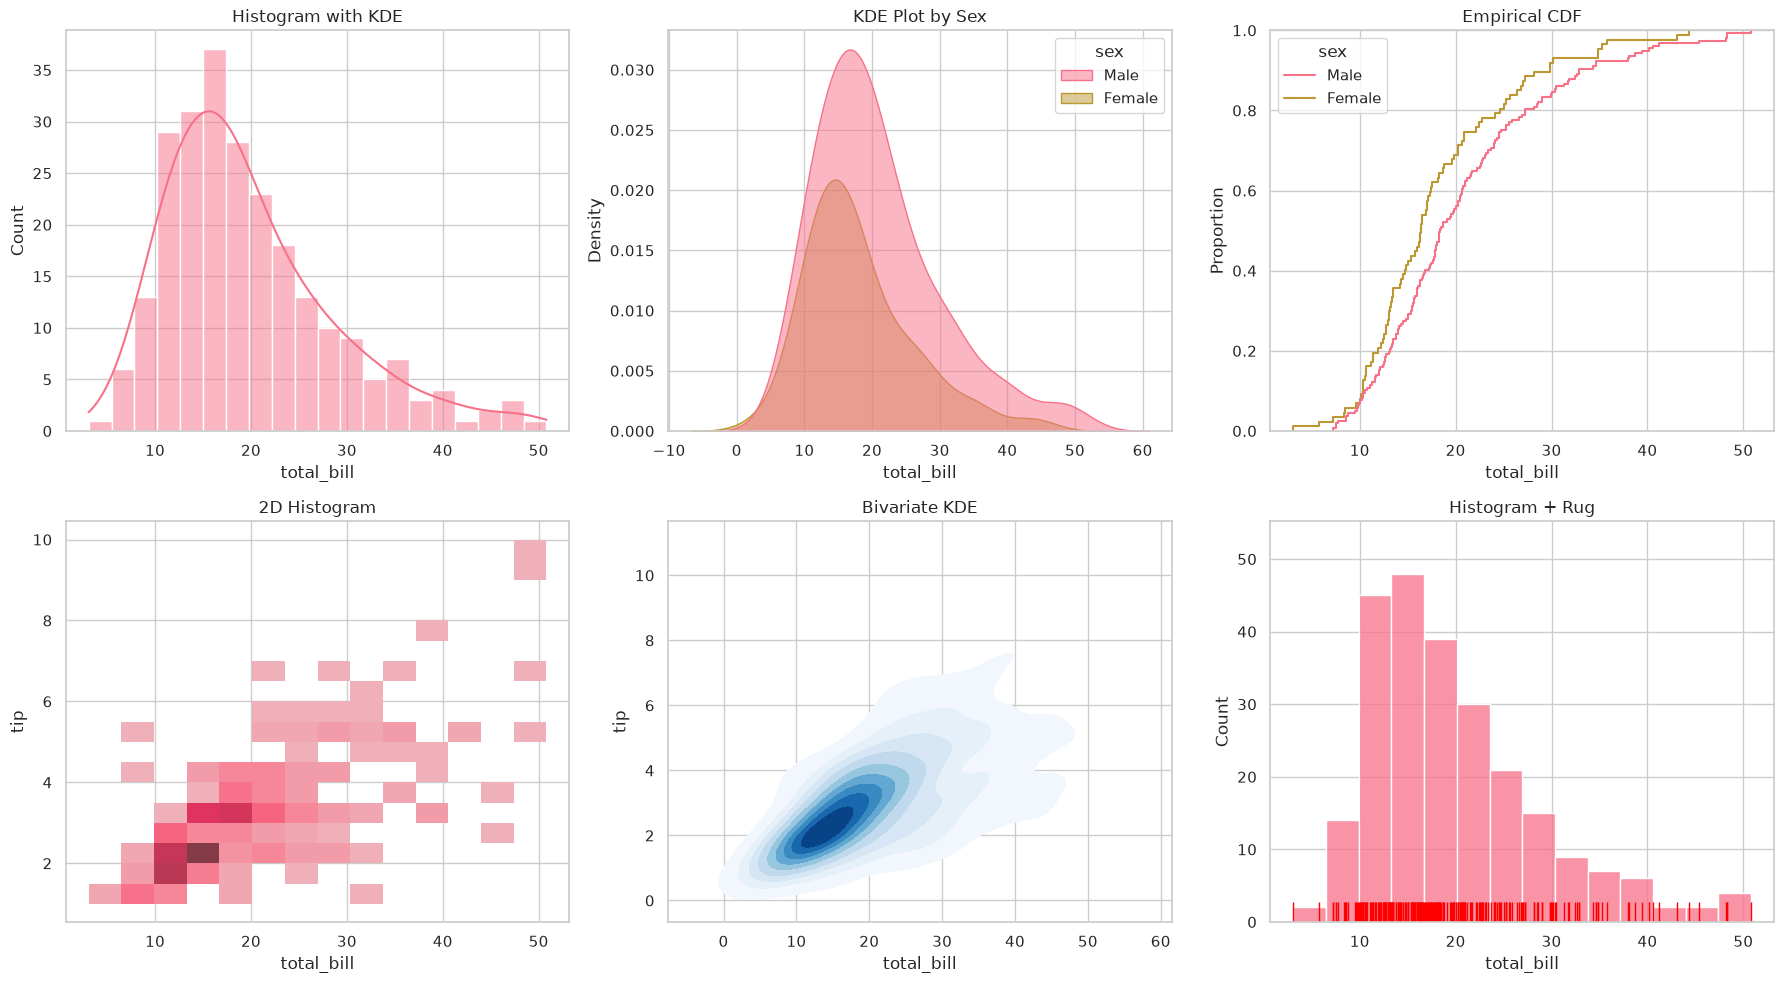

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Histogram
sns.histplot(data=tips, x='total_bill', bins=20, kde=True, ax=axes[0,0])
axes[0,0].set_title('Histogram with KDE')

# KDE plot
sns.kdeplot(data=tips, x='total_bill', hue='sex', fill=True, alpha=0.5, ax=axes[0,1])
axes[0,1].set_title('KDE Plot by Sex')

# ECDF plot
sns.ecdfplot(data=tips, x='total_bill', hue='sex', ax=axes[0,2])
axes[0,2].set_title('Empirical CDF')

# Bivariate distribution
sns.histplot(data=tips, x='total_bill', y='tip', ax=axes[1,0])
axes[1,0].set_title('2D Histogram')

# Bivariate KDE
sns.kdeplot(data=tips, x='total_bill', y='tip', fill=True, cmap='Blues', ax=axes[1,1])
axes[1,1].set_title('Bivariate KDE')

# rug plot
sns.histplot(data=tips, x='total_bill', ax=axes[1,2])
sns.rugplot(data=tips, x='total_bill', ax=axes[1,2], height=0.05, color='red')
axes[1,2].set_title('Histogram + Rug')

plt.tight_layout()
plt.savefig('/tmp/sns_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Categorical Plots

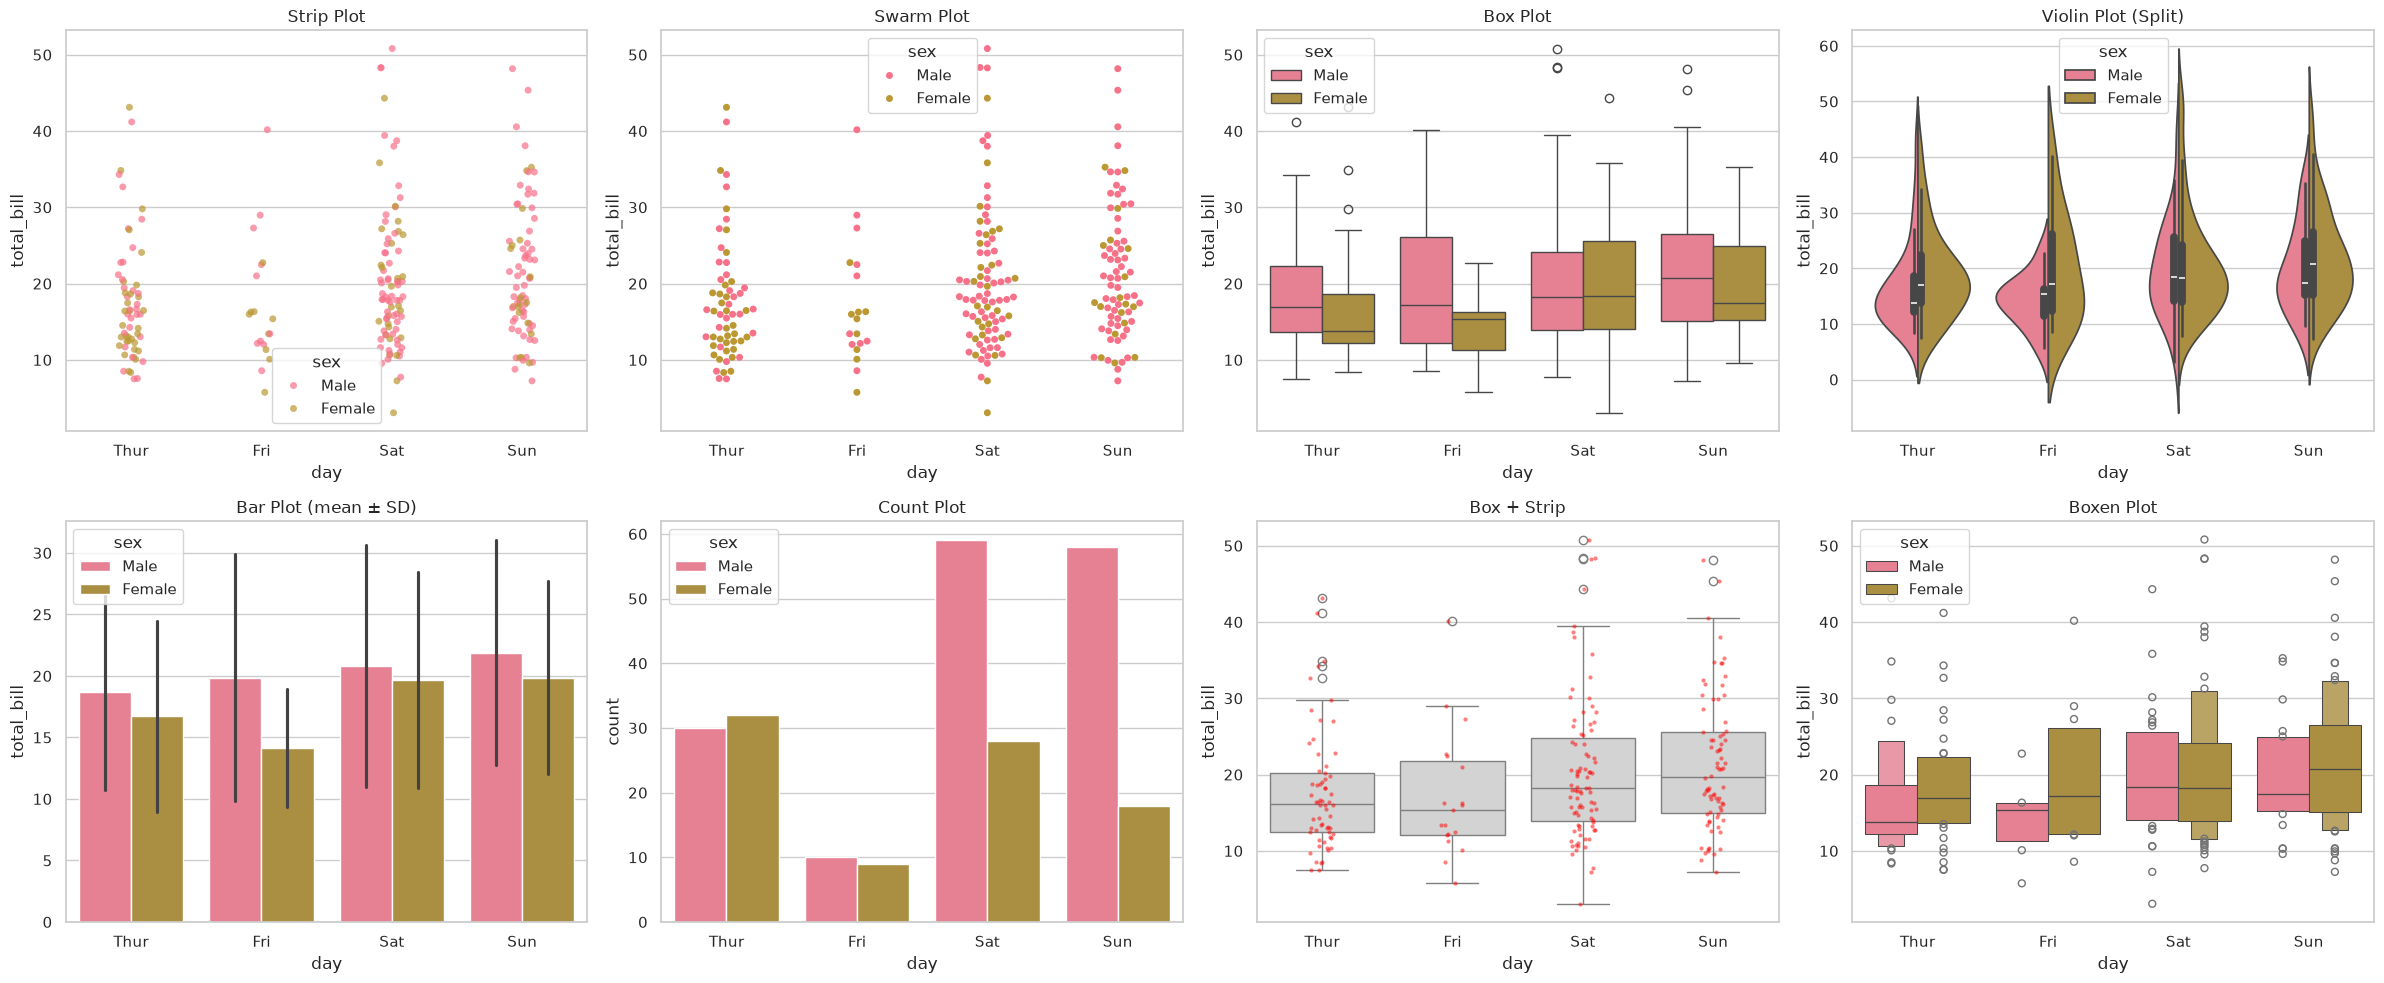

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

# Strip plot
sns.stripplot(data=tips, x='day', y='total_bill', hue='sex',
              jitter=True, alpha=0.7, ax=axes[0,0])
axes[0,0].set_title('Strip Plot')

# Swarm plot
sns.swarmplot(data=tips, x='day', y='total_bill', hue='sex', ax=axes[0,1])
axes[0,1].set_title('Swarm Plot')

# Box plot
sns.boxplot(data=tips, x='day', y='total_bill', hue='sex', ax=axes[0,2])
axes[0,2].set_title('Box Plot')

# Violin plot
sns.violinplot(data=tips, x='day', y='total_bill', hue='sex',
               split=True, ax=axes[0,3])
axes[0,3].set_title('Violin Plot (Split)')

# Bar plot (with CI)
sns.barplot(data=tips, x='day', y='total_bill', hue='sex',
            estimator='mean', errorbar='sd', ax=axes[1,0])
axes[1,0].set_title('Bar Plot (mean ± SD)')

# Count plot
sns.countplot(data=tips, x='day', hue='sex', ax=axes[1,1])
axes[1,1].set_title('Count Plot')

# Box + strip combined
sns.boxplot(data=tips, x='day', y='total_bill', ax=axes[1,2], color='lightgray')
sns.stripplot(data=tips, x='day', y='total_bill', ax=axes[1,2],
              alpha=0.5, color='red', size=3)
axes[1,2].set_title('Box + Strip')

# Boxen plot (letter-value plot)
sns.boxenplot(data=tips, x='day', y='total_bill', hue='sex', ax=axes[1,3])
axes[1,3].set_title('Boxen Plot')

plt.tight_layout()
plt.savefig('/tmp/sns_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Regression Plots

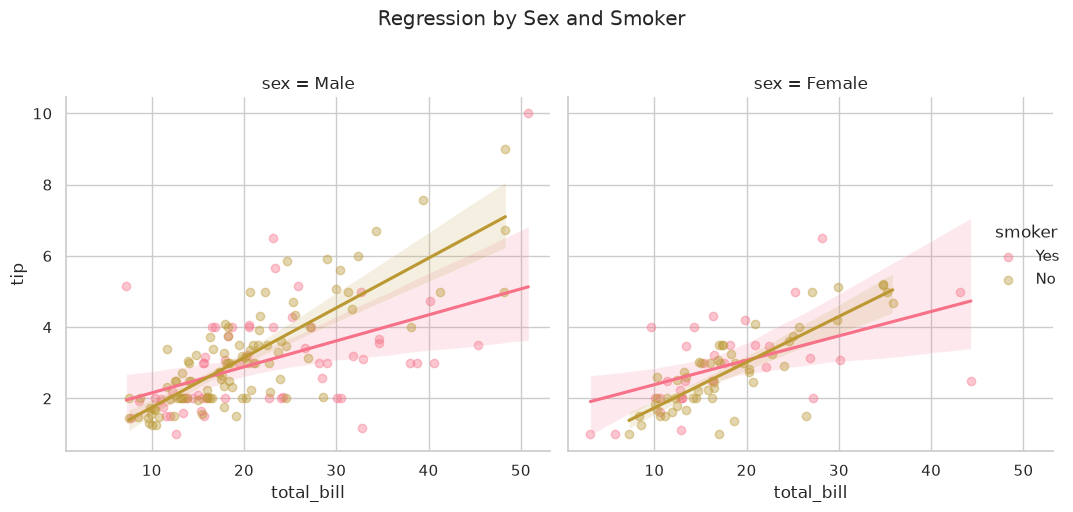

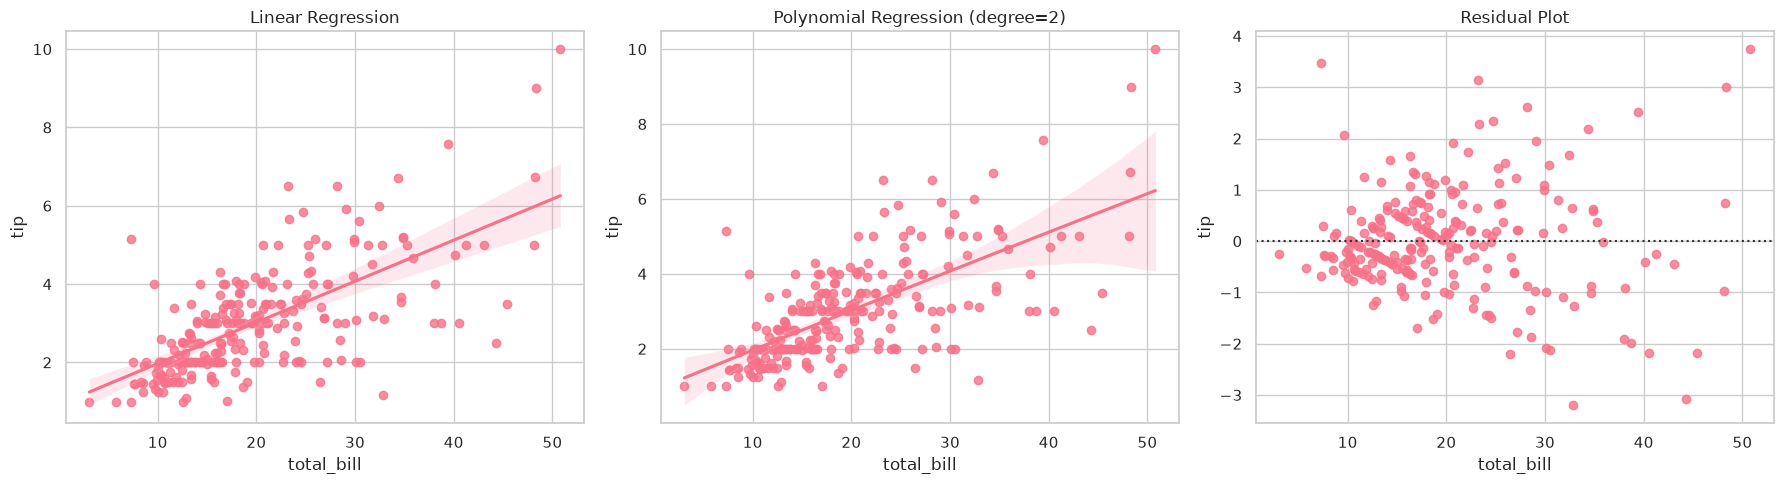

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# lmplot (figure-level with facets)
plt.close()
g = sns.lmplot(data=tips, x='total_bill', y='tip', col='sex',
               hue='smoker', height=5, scatter_kws={'alpha': 0.4})
g.fig.suptitle('Regression by Sex and Smoker', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sns_lmplot.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# regplot basic regression
sns.regplot(data=tips, x='total_bill', y='tip', ax=axes[0])
axes[0].set_title('Linear Regression')

# regplot polynomial
sns.regplot(data=tips, x='total_bill', y='tip', order=2, ax=axes[1])
axes[1].set_title('Polynomial Regression (degree=2)')

# residplot
sns.residplot(data=tips, x='total_bill', y='tip', ax=axes[2])
axes[2].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('/tmp/sns_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Heatmap and Clustermap

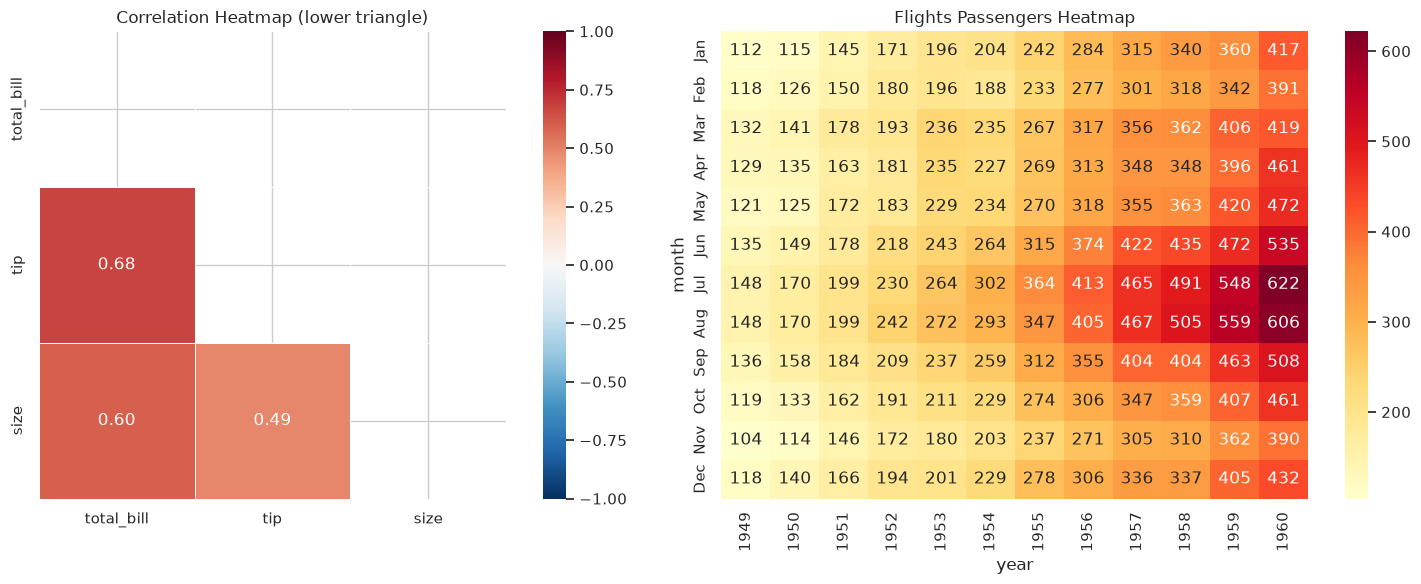

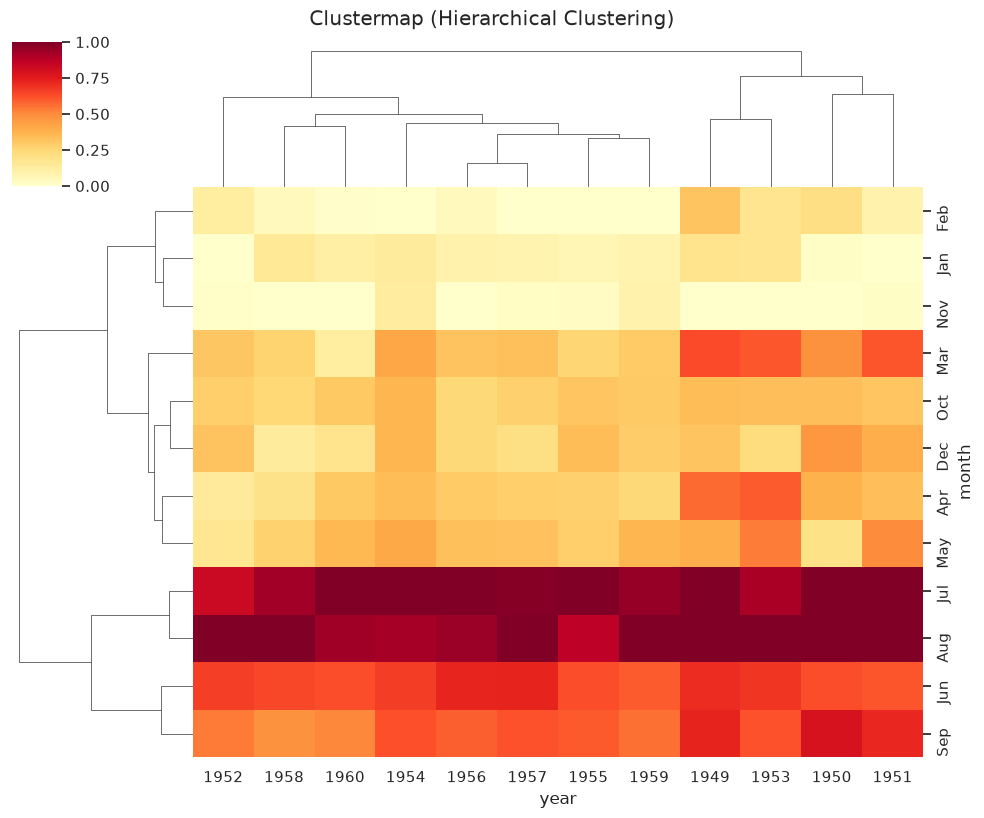

In [6]:
# Heatmap correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr = tips.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            mask=mask, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlation Heatmap (lower triangle)')

# Flights heatmap (pivot)
flights_pivot = flights.pivot_table(index='month', columns='year', values='passengers')
sns.heatmap(flights_pivot.astype(int), annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Flights Passengers Heatmap')

plt.tight_layout()
plt.savefig('/tmp/sns_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Clustermap hierarchically clustered heatmap
g = sns.clustermap(flights_pivot, cmap='YlOrRd', figsize=(10, 8),
                   standard_scale=1)  # normalize per row
g.fig.suptitle('Clustermap (Hierarchical Clustering)', y=1.02)
plt.savefig('/tmp/sns_clustermap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. PairPlot

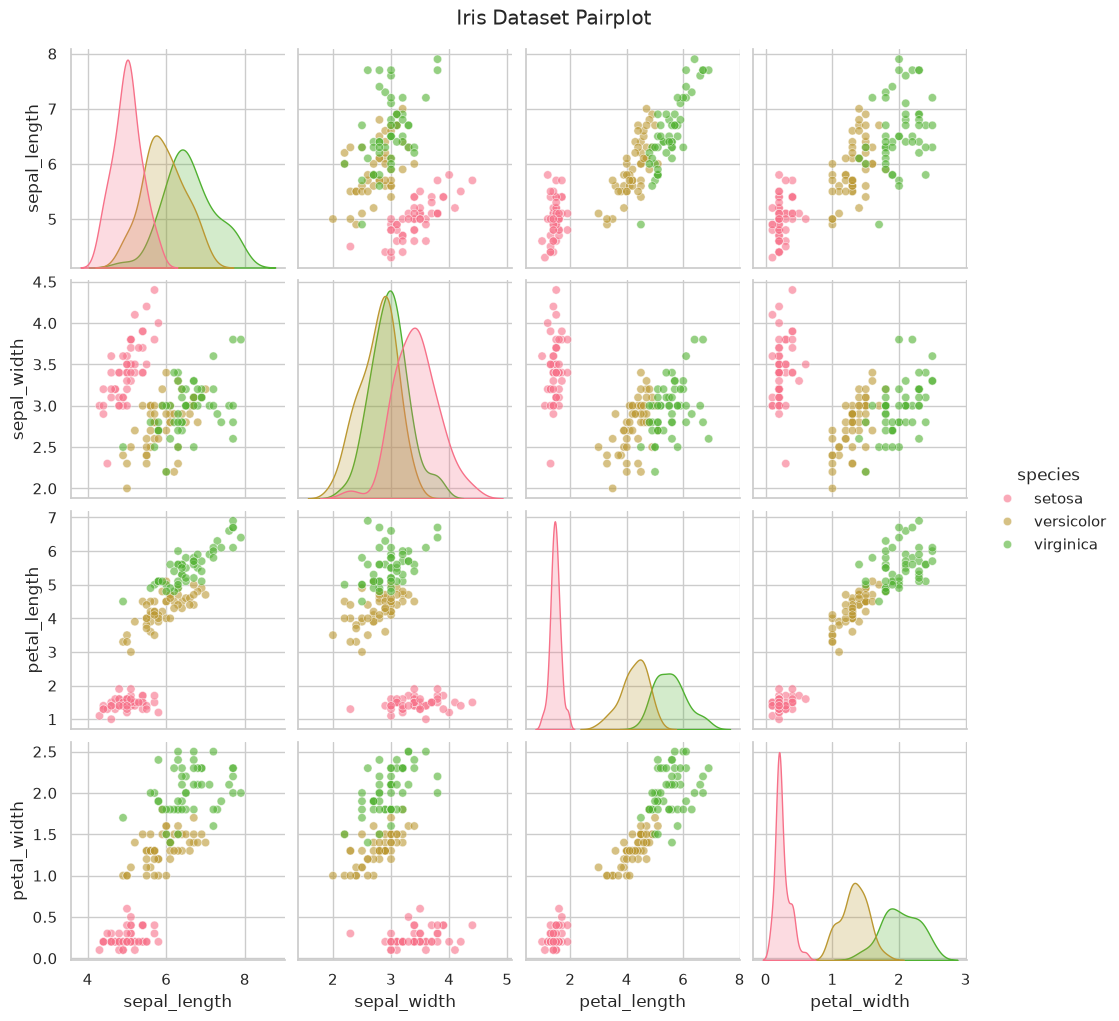

In [7]:
# pairplot all pairwise relationships
g = sns.pairplot(iris, hue='species',
                 diag_kind='kde',      # diagonal: kde or hist
                 plot_kws={'alpha': 0.6},
                 height=2.5)
g.fig.suptitle('Iris Dataset Pairplot', y=1.02)
plt.savefig('/tmp/sns_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. JointPlot

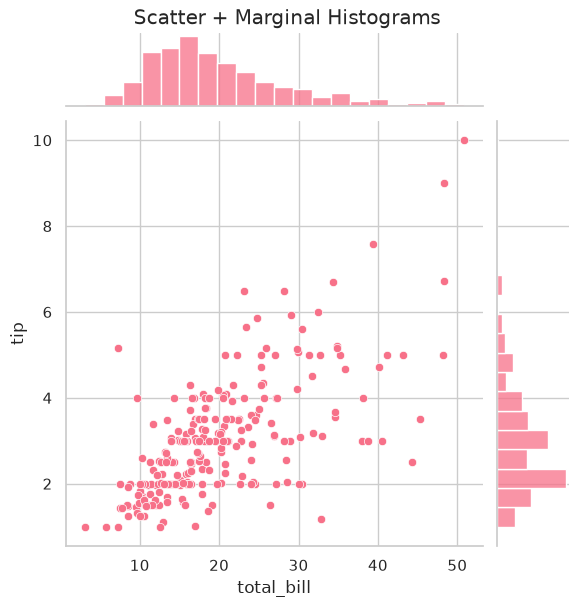

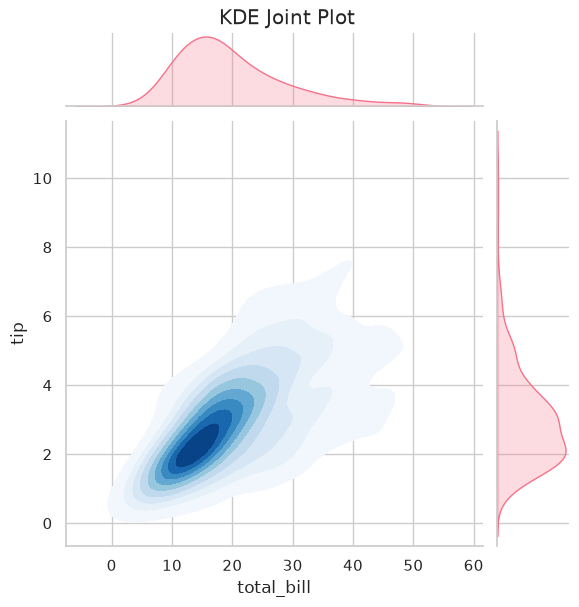

In [8]:
# jointplot bivariate + marginal distributions
fig, axes_jp = plt.subplots(1, 2, figsize=(14, 6))
plt.close()

# Scatter + hist
g1 = sns.jointplot(data=tips, x='total_bill', y='tip',
                   kind='scatter', height=6,
                   marginal_kws=dict(bins=20))
g1.fig.suptitle('Scatter + Marginal Histograms', y=1.01)
plt.savefig('/tmp/sns_joint1.png', dpi=150, bbox_inches='tight')
plt.show()

# KDE joint
g2 = sns.jointplot(data=tips, x='total_bill', y='tip',
                   kind='kde', height=6, fill=True, cmap='Blues')
g2.fig.suptitle('KDE Joint Plot', y=1.01)
plt.savefig('/tmp/sns_joint2.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. FacetGrid

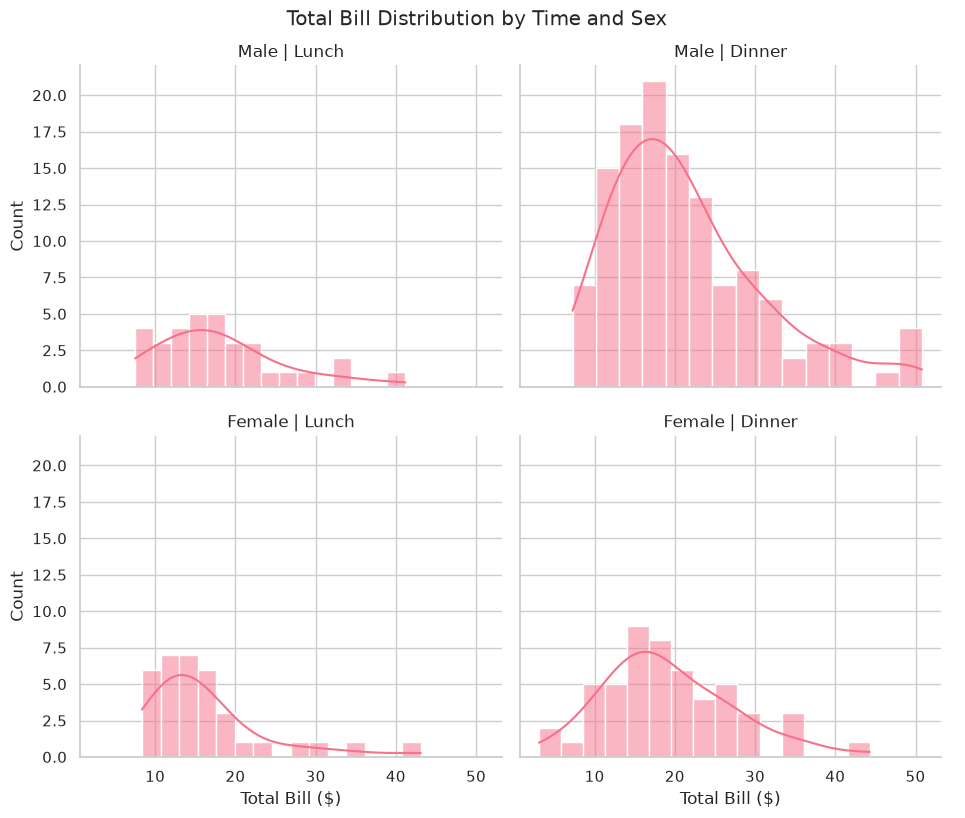

In [9]:
# FacetGrid custom multi-panel plots
g = sns.FacetGrid(tips, col='time', row='sex', height=4, aspect=1.2)
g.map_dataframe(sns.histplot, x='total_bill', bins=15, kde=True)
g.set_titles(col_template='{col_name}', row_template='{row_name}')
g.set_axis_labels('Total Bill ($)', 'Count')
g.add_legend()
g.fig.suptitle('Total Bill Distribution by Time and Sex', y=1.02)
plt.savefig('/tmp/sns_facetgrid.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Themes and Color Palettes

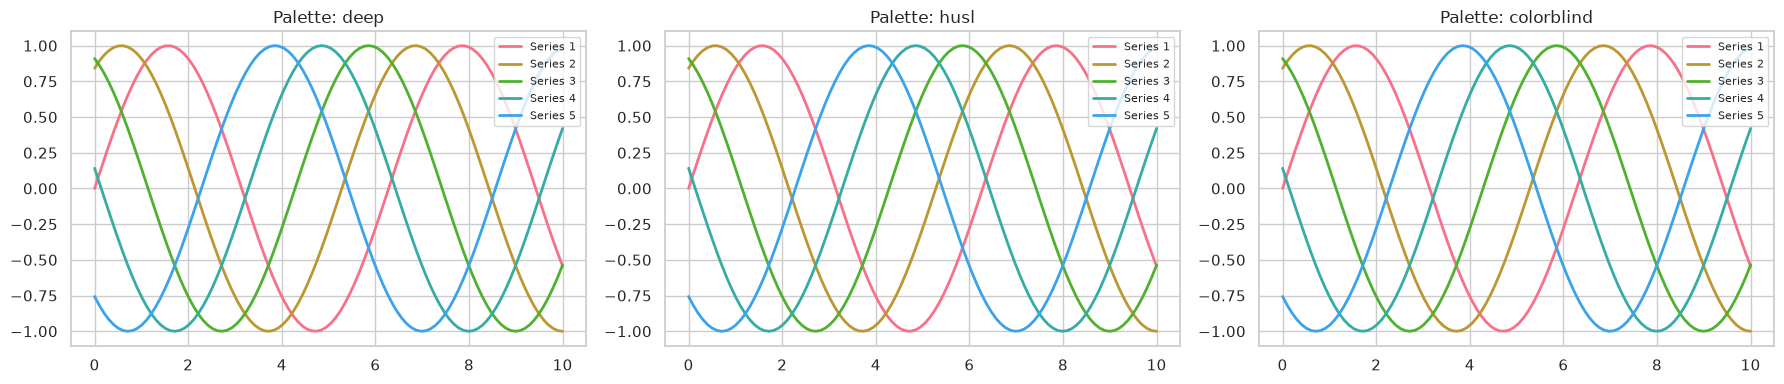

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.8087954113106306, 0.5634700050056693, 0.19502642696727285),
 (0.5920891529639701, 0.6418467016378244, 0.1935069134991043),
 (0.19783576093349015, 0.6955516966063037, 0.3995301037444499),
 (0.21044753832183283, 0.6773105080456748, 0.6433941168468681),
 (0.22335772267769388, 0.6565792317435265, 0.8171355503265633),
 (0.6423044349219739, 0.5497680051256467, 0.9582651433656727),
 (0.96038885399407, 0.3814317878772117, 0.8683117650835491)]

In [10]:
# Seaborn themes
# style: 'darkgrid', 'whitegrid', 'dark', 'white', 'ticks'
# context: 'paper', 'notebook', 'talk', 'poster' (scales font/line size)

# Color palettes
# Qualitative: 'deep', 'muted', 'pastel', 'bright', 'dark', 'colorblind', 'husl', 'tab10'
# Sequential: 'Blues', 'Reds', 'Greens', 'viridis', 'rocket', 'mako', 'flare'
# Diverging: 'RdBu', 'coolwarm', 'vlag', 'icefire'

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

palettes = ['deep', 'husl', 'colorblind']
for ax, pal in zip(axes, palettes):
    sns.set_palette(pal)
    for i in range(5):
        x_vals = np.linspace(0, 10, 100)
        ax.plot(x_vals, np.sin(x_vals + i), linewidth=2, label=f'Series {i+1}')
    ax.set_title(f'Palette: {pal}')
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('/tmp/sns_palettes.png', dpi=150, bbox_inches='tight')
plt.show()

# Reset
sns.set_theme(style='whitegrid', palette='husl')

# Visualize a palette
sns.color_palette('husl', 8)

## 10. Statistical Estimation

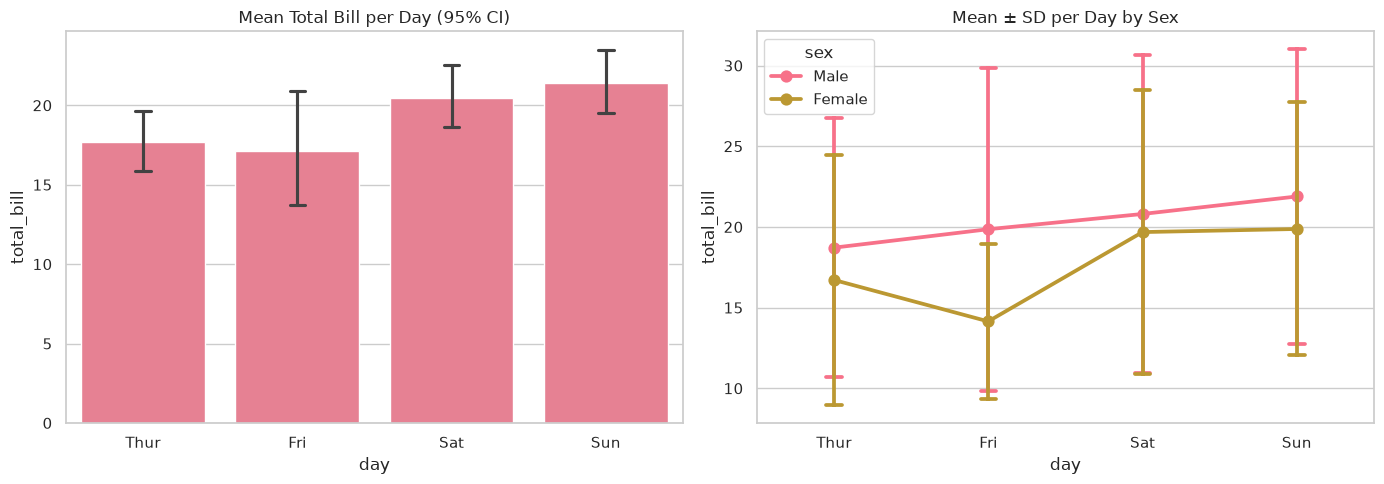

In [11]:
# Seaborn automatically computes CI (confidence intervals) and error bars
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# barplot shows mean + 95% CI by default
sns.barplot(data=tips, x='day', y='total_bill',
            estimator='mean', errorbar=('ci', 95),
            capsize=0.1, ax=axes[0])
axes[0].set_title('Mean Total Bill per Day (95% CI)')

# pointplot for connected category means
sns.pointplot(data=tips, x='day', y='total_bill', hue='sex',
              estimator='mean', errorbar='sd',
              capsize=0.1, ax=axes[1])
axes[1].set_title('Mean ± SD per Day by Sex')

plt.tight_layout()
plt.savefig('/tmp/sns_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## Additional Learning Resources

### Official Documentation
- **Seaborn Official Docs**: https://seaborn.pydata.org/
- **Seaborn Tutorial**: https://seaborn.pydata.org/tutorial.html
- **Seaborn API Reference**: https://seaborn.pydata.org/api.html
- **Seaborn Gallery**: https://seaborn.pydata.org/examples/index.html

### Video Tutorials
- **Seaborn Tutorial** Corey Schafer: https://www.youtube.com/watch?v=6GUZXDef2U0
- **Data Visualization with Seaborn** freeCodeCamp: https://www.youtube.com/watch?v=6GUZXDef2U0

### Books and Guides
- **Python Data Science Handbook** Jake VanderPlas: https://jakevdp.github.io/PythonDataScienceHandbook/
- **Python Graph Gallery (Seaborn)**: https://python-graph-gallery.com/seaborn/

### Paper
- **Seaborn: Statistical Data Visualization** Michael Waskom (2021): https://joss.theoj.org/papers/10.21105/joss.03021